In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
path = '../Data/Economic_data'
df_UR_global = pd.read_csv(f'{path}/Unemployment_rate_nationwide.csv')
df_UR_WI = pd.read_csv(f'{path}/Unemployment_rate_Wisconsin.csv')
df_UR_TX = pd.read_csv(f'{path}/Unemployment_rate_Texas.csv')
df_UR_CA = pd.read_csv(f'{path}/Unemployment_rate_California.csv')

In [3]:
df_UR_global = df_UR_global.rename(columns={'observation_date': 'date', 'UNRATE': 'ur_nation'})
df_UR_WI = df_UR_WI.rename(columns={'observation_date': 'date', 'WIUR': 'ur_WI'})
df_UR_TX = df_UR_TX.rename(columns={'observation_date': 'date', 'TXUR': 'ur_TX'})
df_UR_CA = df_UR_CA.rename(columns={'observation_date': 'date', 'CAUR': 'ur_CA'})

In [4]:
df_UR_ALL = df_UR_global.merge(df_UR_WI, on='date')
df_UR_ALL = df_UR_ALL.merge(df_UR_TX, on='date')
df_UR_ALL = df_UR_ALL.merge(df_UR_CA, on='date')

In [5]:
df_UR_ALL.head()

,date,ur_nation,ur_WI,ur_TX,ur_CA
0,2011-01-01,9.1,7.8,8.2,12.1
1,2011-02-01,9.0,7.7,8.2,12.0
2,2011-03-01,9.0,7.6,8.1,11.9
3,2011-04-01,9.1,7.6,8.1,11.9
4,2011-05-01,9.0,7.6,8.2,11.9


In [6]:
df_UR_ALL['ur_ALL_avg'] = df_UR_ALL[['ur_WI', 'ur_TX', 'ur_CA']].mean(axis=1).round(1)

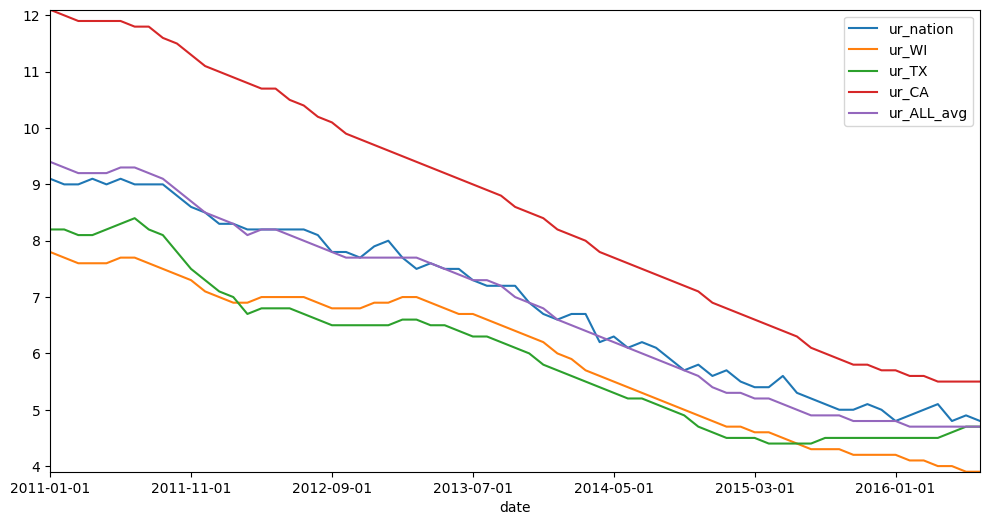

In [7]:
ax = df_UR_ALL.plot(x='date', figsize=(12,6))
ax.set_ylim(bottom=0)

plt.autoscale(enable=True, tight=True)
plt.show()

In [8]:
df_UR_ALL.to_csv('../Data/Derived_data/UR_ALL.csv', index=False)